# Delhivery Logistics Network Analysis

## Problem Statement
Delhivery operates one of India's largest logistics networks across India.
Every delivery has an estimated travel time and an actual time.
The gap between these two is where operational inefficiency hides.

This analysis examines 144,000+ shipment records to answer:
- How delayed is the network overall?
- Which routes and corridors are underperforming?
- What time patterns drive delays?
- How much time is the network losing daily to inefficiency?

In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [ ]:
df = pd.read_csv("delhivery.csv")

print("shape:", df.shape)
print("unique trips:", df["trip_uuid"].nunique())
print("route types:", df["route_type"].value_counts().to_dict())
print("date range:", df["trip_creation_time"].min(), "→", df["trip_creation_time"].max())
print("\nnulls:")
print(df.isnull().sum())

shape: (144867, 24)
unique trips: 14817
route types: {'FTL': 99660, 'Carting': 45207}
date range: 2018-09-12 00:00:16.535741 → 2018-10-03 23:59:42.701692

nulls:
data                                0
trip_creation_time                  0
route_schedule_uuid                 0
route_type                          0
trip_uuid                           0
source_center                       0
source_name                       293
destination_center                  0
destination_name                  261
od_start_time                       0
od_end_time                         0
start_scan_to_end_scan              0
is_cutoff                           0
cutoff_factor                       0
cutoff_timestamp                    0
actual_distance_to_destination      0
actual_time                         0
osrm_time                           0
osrm_distance                       0
factor                              0
segment_actual_time                 0
segment_osrm_time                   0
se

In [ ]:
# parse date columns
df["trip_creation_time"] = pd.to_datetime(df["trip_creation_time"])
df["od_start_time"]      = pd.to_datetime(df["od_start_time"])
df["od_end_time"]        = pd.to_datetime(df["od_end_time"])

# extract hour and day from trip creation time
df["hour"]    = df["trip_creation_time"].dt.hour
df["day"]     = df["trip_creation_time"].dt.day_name()
df["day_num"] = df["trip_creation_time"].dt.dayofweek

print("sample:")
print(df[["trip_creation_time", "hour", "day"]].head(3))

sample:
          trip_creation_time  hour       day
0 2018-09-20 02:35:36.476840     2  Thursday
1 2018-09-20 02:35:36.476840     2  Thursday
2 2018-09-20 02:35:36.476840     2  Thursday


In [ ]:
df["delay_mins"] = df["segment_actual_time"] - df["segment_osrm_time"]

# avoiding division by zero — only calculate pct where osrm_time > 0
df["delay_pct"] = None
mask = df["segment_osrm_time"] > 0
df.loc[mask, "delay_pct"] = (
    df.loc[mask, "delay_mins"] / df.loc[mask, "segment_osrm_time"] * 100
).round(1)

print("avg delay per segment:", round(df["delay_mins"].mean(), 1), "mins")
print("avg delay %          :", round(df["delay_pct"].mean(), 1), "%")

avg delay per segment: 17.7 mins
avg delay %          : 127.1 %


In [ ]:
df["source_city"] = df["source_name"].str.split("_").str[0]
df["dest_city"]   = df["destination_name"].str.split("_").str[0]

df["source_city"] = df["source_city"].fillna("Unknown")
df["dest_city"]   = df["dest_city"].fillna("Unknown")

# Bengaluru and Bangalore are the same city — standardizing to Bangalore
df["source_city"] = df["source_city"].str.replace("Bengaluru", "Bangalore")
df["dest_city"]   = df["dest_city"].str.replace("Bengaluru", "Bangalore")

df["corridor"] = df["source_city"] + " → " + df["dest_city"]

print("sample corridors after fix:")
print(df["corridor"].value_counts().head(5))

sample corridors after fix:
corridor
Bangalore → Bangalore    5071
Gurgaon → Bangalore      4976
Bangalore → Gurgaon      3394
Gurgaon → Kolkata        2862
Gurgaon → Hyderabad      1639
Name: count, dtype: int64


In [ ]:
# group all segments of a trip together
trip_df = df.groupby("trip_uuid").agg(
    route_type       = ("route_type", "first"),
    source_city      = ("source_city", "first"),
    dest_city        = ("dest_city", "last"),
    corridor         = ("corridor", "first"),
    hour             = ("hour", "first"),
    day              = ("day", "first"),
    day_num          = ("day_num", "first"),
    actual_time      = ("segment_actual_time", "sum"),
    estimated_time   = ("segment_osrm_time", "sum"),
    total_delay_mins = ("delay_mins", "sum"),
    num_segments     = ("trip_uuid", "count")
).reset_index()

print("trips shape:", trip_df.shape)
print(trip_df.head(3))

trips shape: (14817, 12)
                 trip_uuid route_type source_city   dest_city  \
0  trip-153671041653548748        FTL      Bhopal     Gurgaon   
1  trip-153671042288605164    Carting      Tumkur  Chikblapur   
2  trip-153671043369099517        FTL   Bangalore  Chandigarh   

              corridor  hour        day  day_num  actual_time  estimated_time  \
0      Bhopal → Kanpur     0  Wednesday        2       1548.0          1008.0   
1  Tumkur → Doddablpur     0  Wednesday        2        141.0            65.0   
2  Bangalore → Gurgaon     0  Wednesday        2       3308.0          1941.0   

   total_delay_mins  num_segments  
0             540.0            39  
1              76.0             9  
2            1367.0            89  


In [ ]:
# trip delay factor = how many times longer than estimated
# factor 2.0 means the trip took twice as long as expected
trip_df["trip_factor"] = trip_df["actual_time"] / trip_df["estimated_time"]
trip_df["trip_factor"] = trip_df["trip_factor"].round(2)

# flag trips that are more than 10% over estimate
trip_df["is_delayed"] = (trip_df["trip_factor"] > 1.1).astype(int)

delayed_pct = round(trip_df["is_delayed"].mean() * 100, 1)
avg_factor  = round(trip_df["trip_factor"].mean(), 2)

print("delayed trips    :", delayed_pct, "%")
print("avg delay factor :", avg_factor)
print("(factor 2.0 = trip took 2x longer than estimated)")

delayed trips    : 95.7 %
avg delay factor : 2.46
(factor 2.0 = trip took 2x longer than estimated)


In [ ]:
conn = sqlite3.connect(":memory:")

df.to_sql("segments", conn, if_exists="replace", index=False)
trip_df.to_sql("trips", conn, if_exists="replace", index=False)

def sql(q):
    return pd.read_sql(q, conn)

print("segments:", sql("SELECT COUNT(*) as n FROM segments").iloc[0,0])
print("trips   :", sql("SELECT COUNT(*) as n FROM trips").iloc[0,0])

segments: 144867
trips   : 14817


In [ ]:
# Overall Network Performance — What is the baseline?
sql("""
    SELECT
        COUNT(*)                                      AS total_trips,
        ROUND(AVG(trip_factor), 2)                    AS avg_delay_factor,
        ROUND(AVG(total_delay_mins), 1)               AS avg_delay_mins,
        ROUND(SUM(is_delayed) * 100.0 / COUNT(*), 1)  AS pct_delayed
    FROM trips
""")

,total_trips,avg_delay_factor,avg_delay_mins,pct_delayed
0,14817,2.46,172.9,95.7


In [ ]:
### FTL vs Carting — Which route type is more delayed?
sql("""
    SELECT
        route_type,
        COUNT(*)                                      AS total_trips,
        ROUND(AVG(trip_factor), 2)                    AS avg_delay_factor,
        ROUND(AVG(total_delay_mins), 1)               AS avg_delay_mins,
        ROUND(SUM(is_delayed) * 100.0 / COUNT(*), 1)  AS pct_delayed
    FROM trips
    GROUP BY route_type
    ORDER BY avg_delay_factor DESC
""")

,route_type,total_trips,avg_delay_factor,avg_delay_mins,pct_delayed
0,Carting,8908,2.68,70.8,94.3
1,FTL,5909,2.14,326.9,97.8


In [ ]:
# Worst Performing Corridors — Where are delays concentrated?
sql("""
    SELECT
        corridor,
        COUNT(*)                        AS total_trips,
        ROUND(AVG(trip_factor), 2)      AS avg_delay_factor,
        ROUND(AVG(total_delay_mins), 1) AS avg_delay_mins
    FROM trips
    WHERE source_city != 'Unknown'
    AND dest_city != 'Unknown'
    AND source_city != dest_city
    GROUP BY corridor
    HAVING total_trips >= 10
    ORDER BY avg_delay_factor DESC
    LIMIT 10
""")

,corridor,total_trips,avg_delay_factor,avg_delay_mins
0,CCU → Kolkata,61,5.96,117.7
1,PNQ Vadgaon Sheri DPC (Maharashtra) → Pune,19,4.80,115.5
2,Agra → Kirauli,11,4.49,156.8
3,Ghumarwin → Jahu,12,4.37,858.2
4,Noida → Del,40,4.29,53.9
5,Mumbai Hub (Maharashtra) → Bhiwandi,63,4.05,68.8
6,Sonari → Sivasagar,16,3.87,116.9
7,Patancheru → Hyderabad,21,3.76,91.4
8,Mumbai → Mumbai Hub (Maharashtra),93,3.73,44.5
9,Mumbai → Bhiwandi,207,3.73,68.9


In [ ]:
# Best Performing Corridors — Where is the network efficient?
sql("""
    SELECT
        corridor,
        COUNT(*)                        AS total_trips,
        ROUND(AVG(trip_factor), 2)      AS avg_delay_factor,
        ROUND(AVG(total_delay_mins), 1) AS avg_delay_mins
    FROM trips
    WHERE source_city != 'Unknown'
    AND dest_city != 'Unknown'
    AND source_city != dest_city
    GROUP BY corridor
    HAVING total_trips >= 10
    ORDER BY avg_delay_factor ASC
    LIMIT 10
""")

,corridor,total_trips,avg_delay_factor,avg_delay_mins
0,Dindigul → Oddnchtram,11,0.98,-6.2
1,Bhatpara → Mungeli,11,1.02,-13.2
2,Gwalior → Gurgaon,12,1.11,41.8
3,Naraingarh → Lalru,14,1.24,17.3
4,Trivandrum → Neyatinkra,19,1.27,14.4
5,Vadodara → Anand,18,1.28,10.9
6,Salem (Tamil Nadu) → Tirchngode,15,1.30,35.7
7,Sonipat → Gurgaon,86,1.32,40.3
8,Gurgaon → Sonipat,92,1.33,40.7
9,Gulbarga → Humnabad,20,1.37,138.1


In [ ]:
# Delay by Hour — When are trips created that end up most delayed?
sql("""
    SELECT
        hour,
        COUNT(*)                        AS total_trips,
        ROUND(AVG(trip_factor), 2)      AS avg_delay_factor,
        ROUND(AVG(total_delay_mins), 1) AS avg_delay_mins
    FROM trips
    GROUP BY hour
    ORDER BY hour
""")

,hour,total_trips,avg_delay_factor,avg_delay_mins
0,0,994,2.66,137.8
1,1,750,2.45,188.9
2,2,702,2.44,168.9
3,3,652,2.80,167.4
4,4,636,2.75,193.4
5,5,509,2.96,238.0
6,6,611,3.05,150.0
7,7,473,2.47,101.0
8,8,346,2.37,185.1
9,9,324,2.82,167.9


In [ ]:
# Delay by Day of Week — Which day is worst?
sql("""
    SELECT
        day,
        COUNT(*)                                      AS total_trips,
        ROUND(AVG(trip_factor), 2)                    AS avg_delay_factor,
        ROUND(SUM(is_delayed) * 100.0 / COUNT(*), 1)  AS pct_delayed
    FROM trips
    GROUP BY day, day_num
    ORDER BY day_num
""")

,day,total_trips,avg_delay_factor,pct_delayed
0,Monday,1987,2.49,95.8
1,Tuesday,2040,2.45,95.4
2,Wednesday,2739,2.49,95.7
3,Thursday,2106,2.44,95.7
4,Friday,2060,2.49,95.9
5,Saturday,2130,2.55,95.7
6,Sunday,1755,2.31,96.1


In [ ]:
# Worst Source Cities — Which dispatch centers cause most delays?
sql("""
    SELECT
        source_city,
        COUNT(*)                        AS total_trips,
        ROUND(AVG(trip_factor), 2)      AS avg_delay_factor,
        ROUND(AVG(total_delay_mins), 1) AS avg_delay_mins
    FROM trips
    WHERE source_city != 'Unknown'
    GROUP BY source_city
    HAVING total_trips >= 20
    ORDER BY avg_delay_factor DESC
    LIMIT 10
""")

,source_city,total_trips,avg_delay_factor,avg_delay_mins
0,Allahabad,47,8.28,666.4
1,Margherita,22,7.77,358.8
2,Varanasi,20,5.36,543.5
3,CCU,75,5.32,118.8
4,PNQ Vadgaon Sheri DPC (Maharashtra),28,5.22,117.5
5,Jabalpur,37,4.38,158.8
6,Surat,131,4.12,226.6
7,Muzaffrpur,159,3.88,459.2
8,Guna,21,3.79,521.0
9,Patancheru,21,3.76,91.4


In [ ]:
# Outlier Trips — Which trips are extreme failures?
sql("""
    SELECT
        trip_uuid,
        corridor,
        route_type,
        ROUND(trip_factor, 2)       AS delay_factor,
        ROUND(total_delay_mins, 0)  AS delay_mins,
        num_segments
    FROM trips
    WHERE trip_factor > 10
    ORDER BY trip_factor DESC
    LIMIT 10
""")

,trip_uuid,corridor,route_type,delay_factor,delay_mins,num_segments
0,trip-153761568647456368,Gonda → Balrampur,Carting,82.69,2369.0,5
1,trip-153691774924973666,Surat → Surat,Carting,70.00,759.0,1
2,trip-153700839622813110,Gonda → Tulsipur,Carting,53.89,2486.0,7
3,trip-153682944027974510,Allahabad → Allahabad,Carting,52.89,986.0,3
4,trip-153706705984334815,Allahabad → Allahabad,Carting,38.40,1122.0,5
5,trip-153751878739026869,CCU → Kolkata,Carting,37.19,977.0,2
6,trip-153809667984245845,Jabalpur → Jabalpur (Madhya Pradesh),Carting,35.44,551.0,3
7,trip-153704259509954539,Mariani → Jorhat,Carting,32.94,511.0,1
8,trip-153843860882255800,Dhanbad → Dhanbad,Carting,31.55,336.0,1
9,trip-153775088157458469,CCU → Kolkata,Carting,30.60,592.0,1


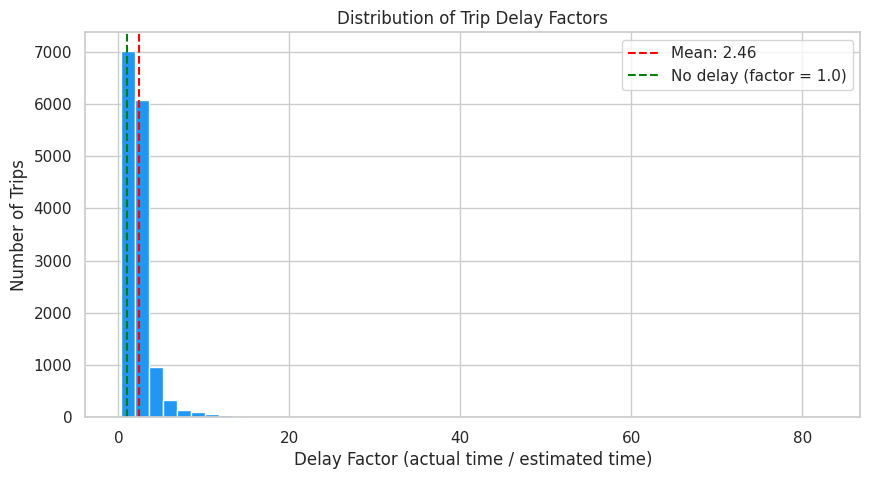

In [ ]:
# Chart 1 — Overall Delay Factor Distribution
# How spread out are delays across all trips?
plt.figure()
plt.hist(trip_df["trip_factor"], bins=50, color="#2196F3", edgecolor="white")
plt.axvline(trip_df["trip_factor"].mean(), color="red", linestyle="--", label=f"Mean: {trip_df['trip_factor'].mean():.2f}")
plt.axvline(1.0, color="green", linestyle="--", label="No delay (factor = 1.0)")
plt.title("Distribution of Trip Delay Factors")
plt.xlabel("Delay Factor (actual time / estimated time)")
plt.ylabel("Number of Trips")
plt.legend()
plt.show()

**Insight:** The bulk of trips cluster between factor 1–5, but a long tail
stretches to 82x. The mean (2.46) is pulled up by extreme outliers-
the median (1.95) tells a slightly better but still critical story.
Even the median means a typical trip takes nearly 2x its estimated time.

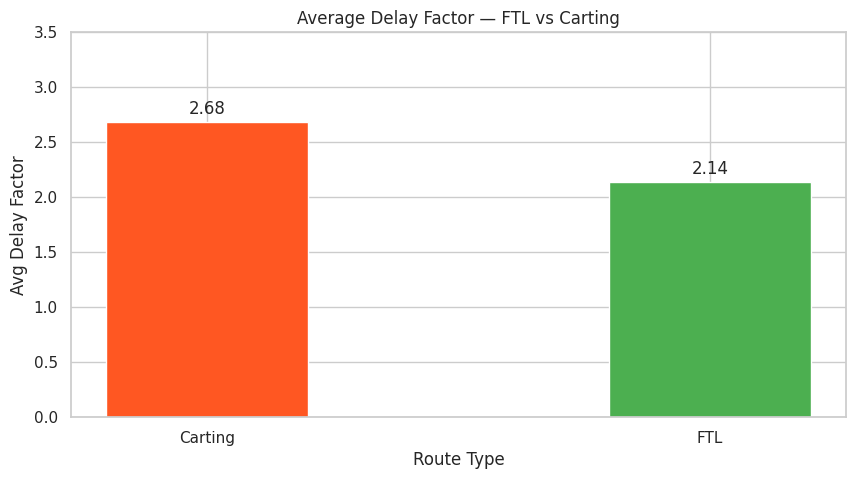

In [ ]:
# Chart 2 — FTL vs Carting Delay Comparison
route_data = trip_df.groupby("route_type")["trip_factor"].mean().reset_index()

plt.figure()
bars = plt.bar(route_data["route_type"], route_data["trip_factor"], color=["#FF5722", "#4CAF50"], width=0.4)
plt.bar_label(bars, fmt="%.2f", padding=3)
plt.title("Average Delay Factor — FTL vs Carting")
plt.xlabel("Route Type")
plt.ylabel("Avg Delay Factor")
plt.ylim(0, 3.5)
plt.show()

**Insight:** Carting is 25% more delayed than FTL on a factor basis.
Carting involves smaller vehicles making multiple urban stops-
each stop adds unpredictability. FTL is one truck, one highway route,
fewer variables. The fix for each is fundamentally different.

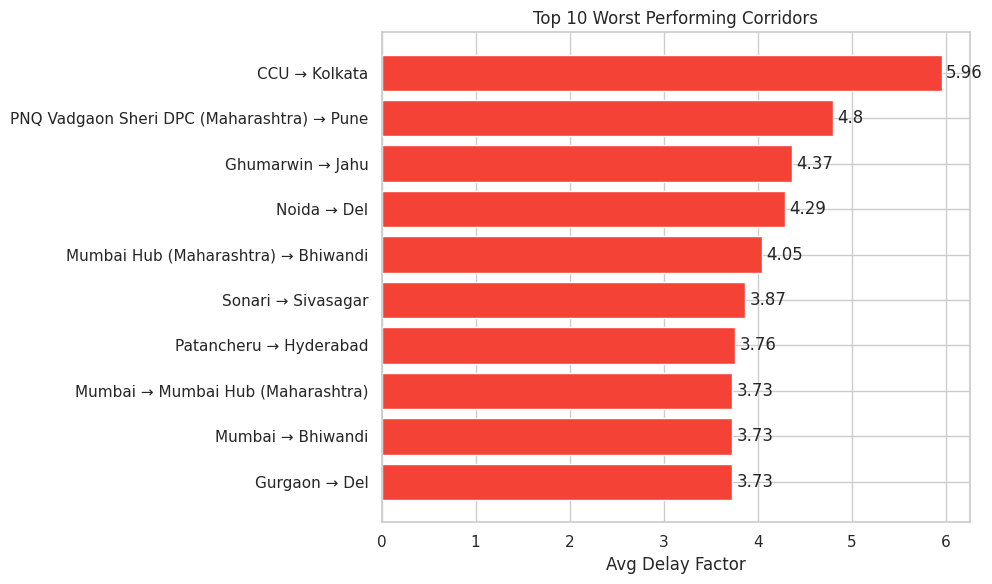

In [ ]:
# Chart 3 — Top 10 Worst Corridors
worst = sql("""
    SELECT corridor, ROUND(AVG(trip_factor), 2) AS avg_factor
    FROM trips
    WHERE source_city != dest_city
    AND source_city != 'Unknown'
    GROUP BY corridor
    HAVING COUNT(*) >= 10
    ORDER BY avg_factor DESC
    LIMIT 10
""")

plt.figure(figsize=(10, 6))
bars = plt.barh(worst["corridor"][::-1], worst["avg_factor"][::-1], color="#F44336")
plt.bar_label(bars, padding=3)
plt.title("Top 10 Worst Performing Corridors")
plt.xlabel("Avg Delay Factor")
plt.tight_layout()
plt.show()

**Insight:** CCU → Kolkata at factor 5.96 stands out- CCU is Kolkata airport's
IATA code, making this an airport-to-city cargo transfer route. Airport handling
bottlenecks, not road conditions, likely drive this delay. Mumbai → Bhiwandi
appearing twice in different forms suggests the entire Mumbai logistics cluster
has a systemic problem worth a dedicated investigation.

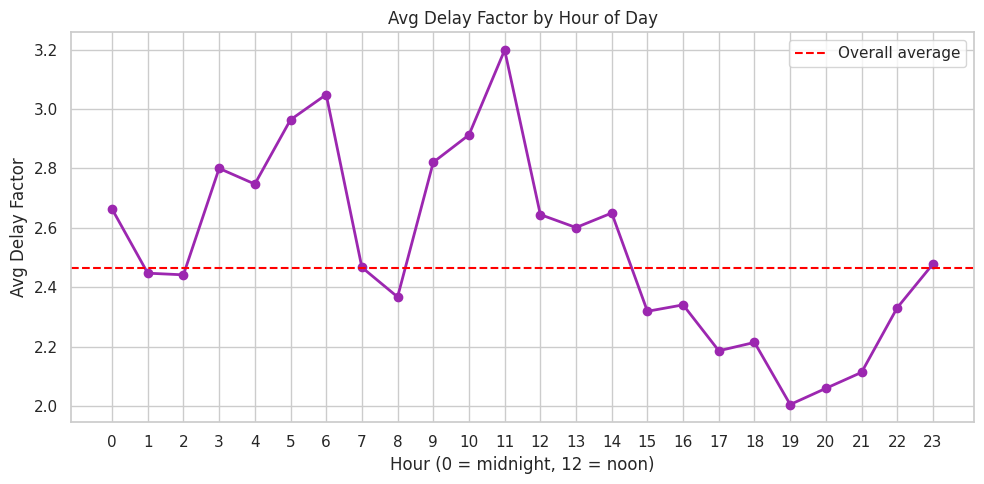

In [ ]:
# Chart 4 — Delay by Hour of Day
hour_data = trip_df.groupby("hour")["trip_factor"].mean().reset_index()

plt.figure()
plt.plot(hour_data["hour"], hour_data["trip_factor"], marker="o", color="#9C27B0", linewidth=2)
plt.axhline(trip_df["trip_factor"].mean(), color="red", linestyle="--", label="Overall average")
plt.title("Avg Delay Factor by Hour of Day")
plt.xlabel("Hour (0 = midnight, 12 = noon)")
plt.ylabel("Avg Delay Factor")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

**Insight:** Trips dispatched at 11am have the worst delay factor (3.20)- 37% worse
than trips dispatched at 7pm (2.01). Morning dispatches hit peak urban traffic
immediately. Evening dispatches benefit from lighter roads. Shifting non-urgent
dispatches to evening hours could reduce delay factor significantly with zero
infrastructure change.

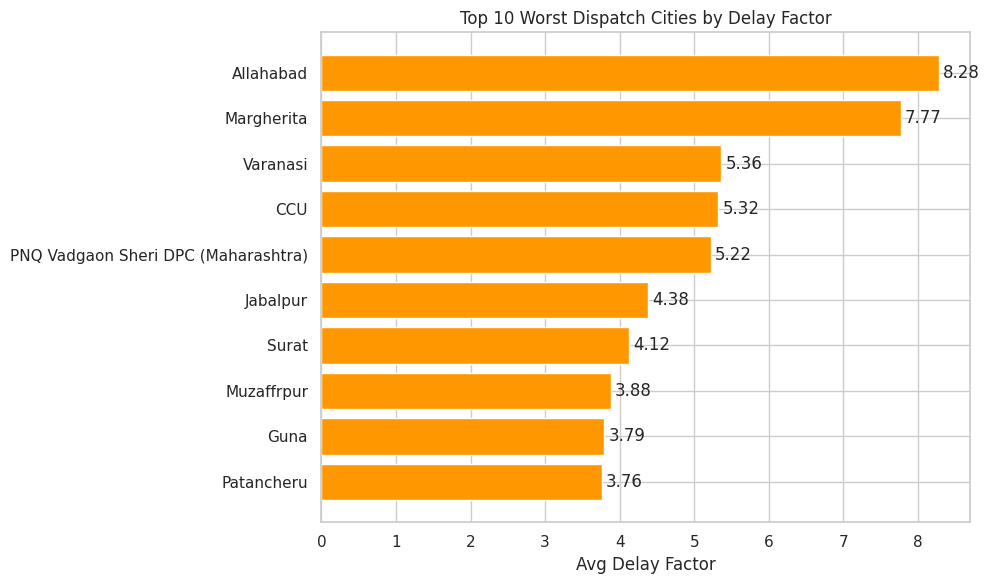

In [ ]:
# Chart 5 — Top 10 Worst Source Cities
city_data = sql("""
    SELECT source_city, ROUND(AVG(trip_factor), 2) AS avg_factor
    FROM trips
    WHERE source_city != 'Unknown'
    GROUP BY source_city
    HAVING COUNT(*) >= 20
    ORDER BY avg_factor DESC
    LIMIT 10
""")

plt.figure(figsize=(10, 6))
bars = plt.barh(city_data["source_city"][::-1], city_data["avg_factor"][::-1], color="#FF9800")
plt.bar_label(bars, padding=3)
plt.title("Top 10 Worst Dispatch Cities by Delay Factor")
plt.xlabel("Avg Delay Factor")
plt.tight_layout()
plt.show()


**Insight:** Allahabad (8.28) and Margherita (7.77) are extreme outliers; nearly
double the third-worst city. They likely need fundamentally different solutions:
Allahabad needs urban last-mile restructuring, Margherita (upper Assam, remote
location) may need alternative transport modes entirely.

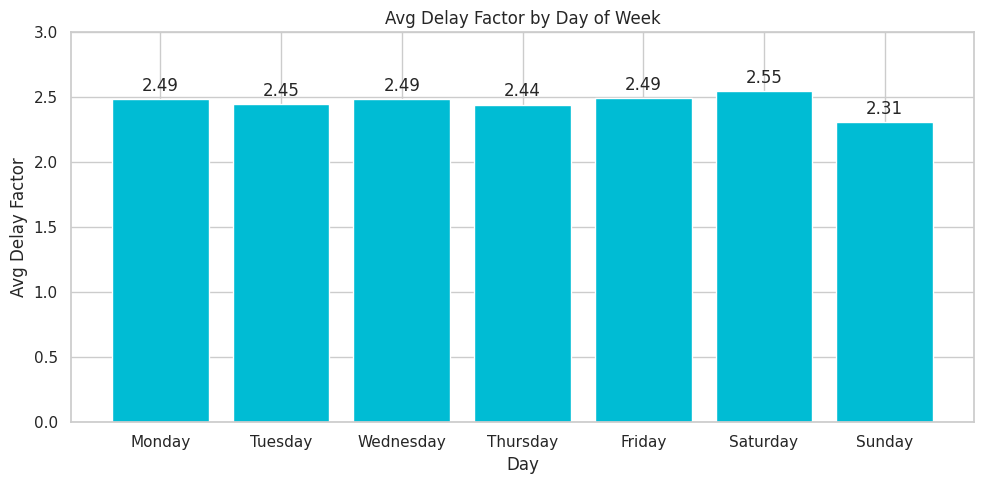

In [ ]:
# Chart 6 — Delay Factor by Day of Week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_data  = trip_df.groupby("day")["trip_factor"].mean().reindex(day_order).reset_index()

plt.figure()
bars = plt.bar(day_data["day"], day_data["trip_factor"], color="#00BCD4")
plt.bar_label(bars, fmt="%.2f", padding=3)
plt.title("Avg Delay Factor by Day of Week")
plt.xlabel("Day")
plt.ylabel("Avg Delay Factor")
plt.ylim(0, 3.0)
plt.tight_layout()
plt.show()

**Insight:** The range across all 7 days is only 0.24- from Sunday (2.31) to
Saturday (2.55). This near-flat pattern confirms the delay problem is structural
and network-wide, not driven by weekly scheduling. No amount of day-of-week
rescheduling will solve a problem this consistent.

## Correlation Analysis: What Actually Drives Delays?

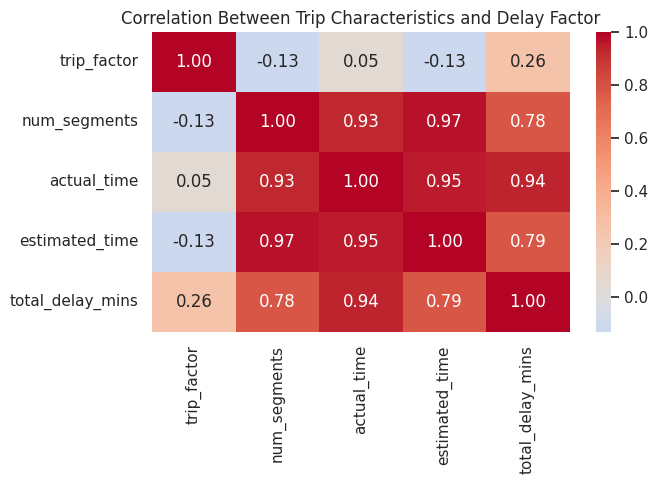

In [ ]:
# Is there a relationship between number of segments and delay factor? More segments = more handoffs = more chances for delay?
corr = trip_df[["trip_factor", "num_segments", "actual_time", "estimated_time", "total_delay_mins"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Trip Characteristics and Delay Factor")
plt.tight_layout()
plt.show()

**Insight:** Trip factor has almost no correlation with number of segments (-0.13)
or trip duration (0.05). This is the most important finding from correlation analysis,
it means delays cannot be explained by trip complexity or length.
The problem lies in estimation accuracy and local operational conditions,
not in how trips are structured.

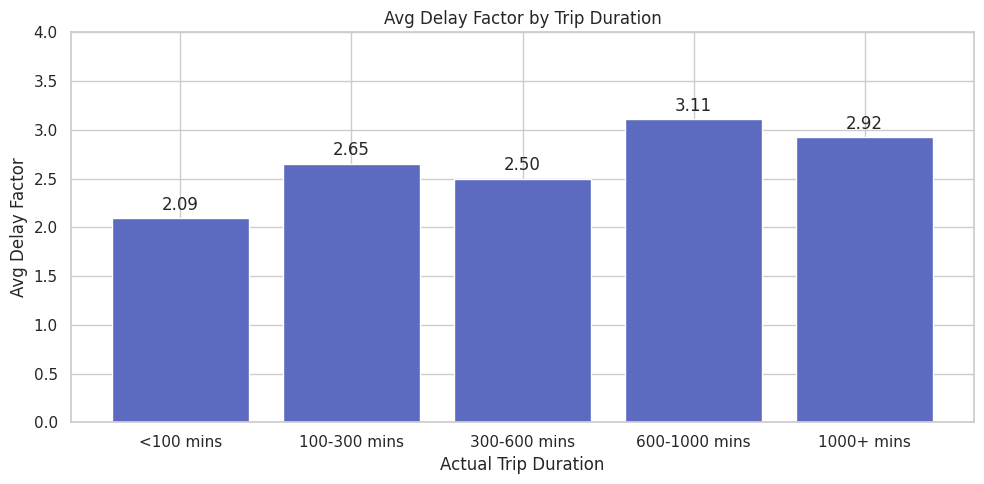

In [ ]:
# Does distance affect delay factor? Longer routes — are they proportionally more or less delayed?
# bucketing actual trip time into ranges for cleaner comparison
trip_df["time_bucket"] = pd.cut(
    trip_df["actual_time"],
    bins=[0, 100, 300, 600, 1000, 99999],
    labels=["<100 mins", "100-300 mins", "300-600 mins", "600-1000 mins", "1000+ mins"]
)

time_delay = trip_df.groupby("time_bucket", observed=True)["trip_factor"].mean().reset_index()

plt.figure()
bars = plt.bar(time_delay["time_bucket"], time_delay["trip_factor"], color="#5C6BC0")
plt.bar_label(bars, fmt="%.2f", padding=3)
plt.title("Avg Delay Factor by Trip Duration")
plt.xlabel("Actual Trip Duration")
plt.ylabel("Avg Delay Factor")
plt.ylim(0, 4.0)
plt.tight_layout()
plt.show()

**Insight:** Medium-haul trips (600–1000 mins) have the worst delay factor (3.11).
Short trips (<100 mins) are most efficient (2.09).
OSRM appears to underestimate medium-haul routes the most;
these are likely state highway routes where actual speeds
are significantly below OSRM's assumptions.

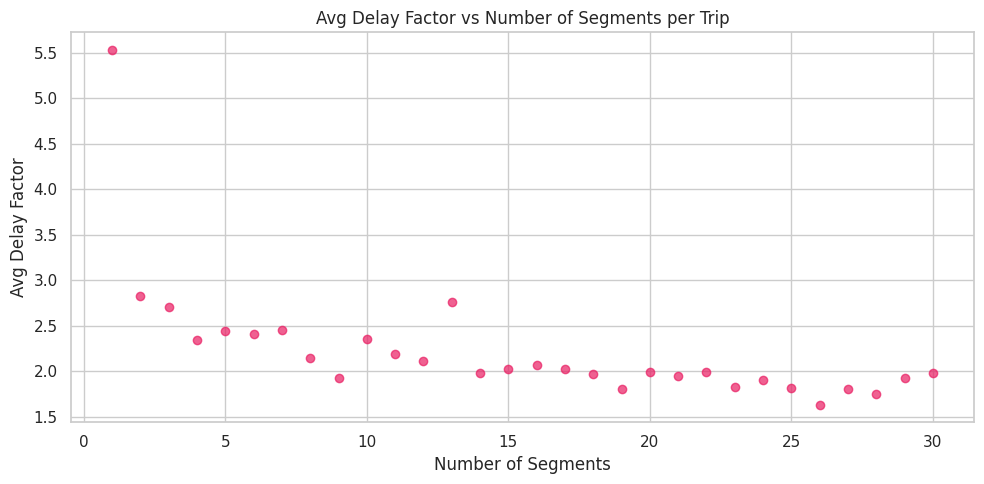

correlation between segments and delay factor: -0.129


In [ ]:
# Does number of segments affect delay factor? Each segment = one warehouse handoff. More handoffs = more delay risk?
# capping at 30 segments to remove extreme outliers from chart
segment_delay = (
    trip_df[trip_df["num_segments"] <= 30]
    .groupby("num_segments")["trip_factor"]
    .mean()
    .reset_index()
)

plt.figure()
plt.scatter(segment_delay["num_segments"], segment_delay["trip_factor"],
            color="#E91E63", alpha=0.7)
plt.title("Avg Delay Factor vs Number of Segments per Trip")
plt.xlabel("Number of Segments")
plt.ylabel("Avg Delay Factor")
plt.tight_layout()
plt.show()

# actual correlation value
corr_val = trip_df["num_segments"].corr(trip_df["trip_factor"])
print(f"correlation between segments and delay factor: {corr_val:.3f}")

**Insight:** Single-segment trips have by far the worst delay factor (5.5) -
worse than trips with 20 or 30 segments. This completely inverts the
intuitive assumption that more handoffs = more delay.
Single-segment Carting trips are point-to-point urban deliveries
with no intermediate checkpoints, when something goes wrong,
there is no mechanism to catch or correct it mid-journey.

## Anomaly Flagging: Identifying Trips That Need Immediate Attention

Flagging statistical outliers - trips and corridors that are
performing far outside normal network behaviour.
A trip is an anomaly if its delay factor is beyond
the 95th percentile of the network.

In [ ]:
# finding the 95th percentile threshold
p95 = trip_df["trip_factor"].quantile(0.95)
print(f"95th percentile delay factor : {p95:.2f}")
print(f"trips above this threshold   : {(trip_df['trip_factor'] > p95).sum()}")
print(f"that is                      : {(trip_df['trip_factor'] > p95).mean()*100:.1f}% of all trips")

# flagging anomalies
anomalies = trip_df[trip_df["trip_factor"] > p95].copy()
anomalies = anomalies.sort_values("trip_factor", ascending=False)

print("\ntop 10 anomaly trips:")
print(anomalies[["corridor", "route_type", "trip_factor", "total_delay_mins", "num_segments"]].head(10).to_string())

95th percentile delay factor : 5.25
trips above this threshold   : 738
that is                      : 5.0% of all trips

top 10 anomaly trips:
                                   corridor route_type  trip_factor  total_delay_mins  num_segments
7574                      Gonda → Balrampur    Carting        82.69            2369.0             5
1807                          Surat → Surat    Carting        70.00             759.0             1
2555                       Gonda → Tulsipur    Carting        53.89            2486.0             7
1023                  Allahabad → Allahabad    Carting        52.89             986.0             3
3089                  Allahabad → Allahabad    Carting        38.40            1122.0             5
6759                          CCU → Kolkata    Carting        37.19             977.0             2
11350  Jabalpur → Jabalpur (Madhya Pradesh)    Carting        35.44             551.0             3
2801                       Mariani → Jorhat    Carting   

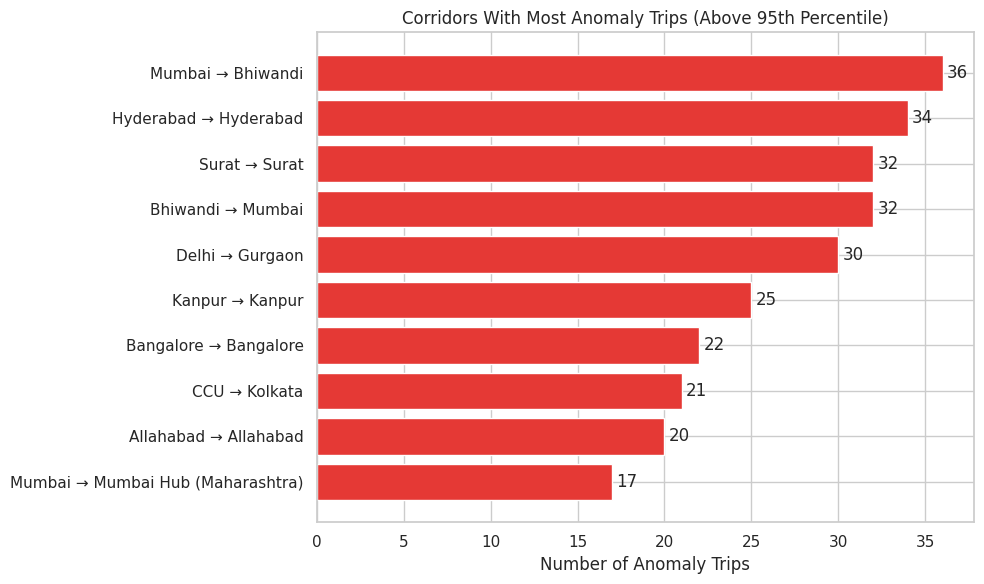

                            corridor  anomaly_trips  avg_factor
0                  Mumbai → Bhiwandi             36        8.53
1              Hyderabad → Hyderabad             34        9.78
2                      Surat → Surat             32        9.86
3                  Bhiwandi → Mumbai             32        7.68
4                    Delhi → Gurgaon             30       10.55
5                    Kanpur → Kanpur             25       11.05
6              Bangalore → Bangalore             22        7.44
7                      CCU → Kolkata             21       11.09
8              Allahabad → Allahabad             20       15.15
9  Mumbai → Mumbai Hub (Maharashtra)             17        7.93


In [ ]:
# which corridors have the most anomaly trips?
anomaly_corridors = (
    anomalies.groupby("corridor")
    .agg(
        anomaly_trips = ("trip_uuid", "count"),
        avg_factor    = ("trip_factor", "mean")
    )
    .sort_values("anomaly_trips", ascending=False)
    .head(10)
    .reset_index()
)

anomaly_corridors["avg_factor"] = anomaly_corridors["avg_factor"].round(2)

plt.figure(figsize=(10, 6))
bars = plt.barh(
    anomaly_corridors["corridor"][::-1],
    anomaly_corridors["anomaly_trips"][::-1],
    color="#E53935"
)
plt.bar_label(bars, padding=3)
plt.title("Corridors With Most Anomaly Trips (Above 95th Percentile)")
plt.xlabel("Number of Anomaly Trips")
plt.tight_layout()
plt.show()

print(anomaly_corridors.to_string())

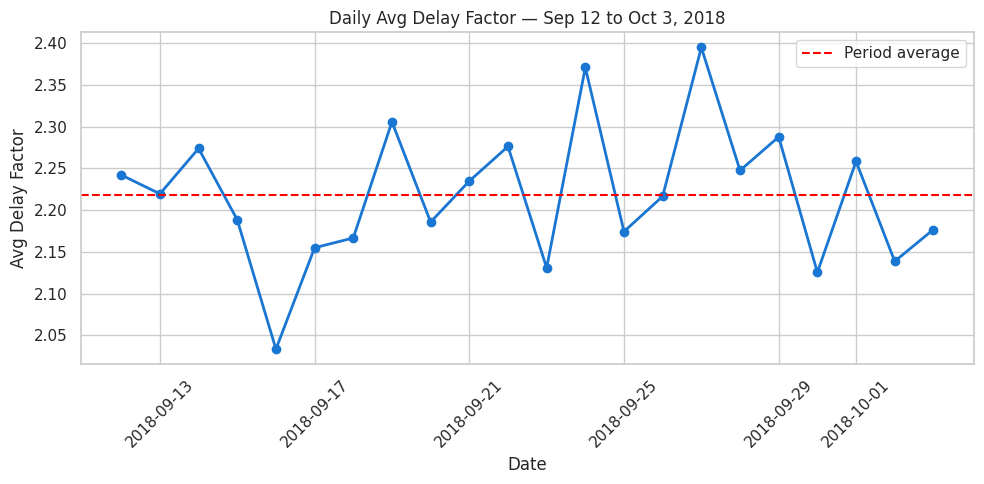

first week avg factor : 2.18
last week avg factor  : 2.23


In [ ]:
daily = trip_df.groupby(trip_df["hour"].map(lambda x: x)).agg(
    avg_factor = ("trip_factor", "mean"),
    trips      = ("trip_uuid", "count")
).reset_index()

# getting daily trend from segments table
df["date"] = df["trip_creation_time"].dt.date

daily_trend = df.groupby("date").agg(
    avg_factor    = ("segment_factor", "mean"),
    total_segs    = ("trip_uuid", "count")
).reset_index()

plt.figure()
plt.plot(daily_trend["date"], daily_trend["avg_factor"], marker="o", color="#1976D2", linewidth=2)
plt.axhline(daily_trend["avg_factor"].mean(), color="red", linestyle="--", label="Period average")
plt.title("Daily Avg Delay Factor — Sep 12 to Oct 3, 2018")
plt.xlabel("Date")
plt.ylabel("Avg Delay Factor")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print("first week avg factor :", round(daily_trend.head(7)["avg_factor"].mean(), 2))
print("last week avg factor  :", round(daily_trend.tail(7)["avg_factor"].mean(), 2))

**Insight:** No improvement across 22 days. The delay factor oscillates
between 2.04 and 2.39 with no downward trend- first week average (2.18)
is actually slightly better than the last week (2.23).
This confirms the delay problem is structural and deeply embedded
in network operations; not a short-term anomaly that will self-correct.

# Recommendations

### 1. The intra-city issue requires an entirely distinct approach.

From the results obtained after analyzing the data, it was anticipated that long interstate routes would pose the major issue. However, this is not the case. The greatest delays have been found to be within the same city, for example, Allahabad to Allahabad with a factor of 15 and Kanpur to Kanpur with a factor of 11. This delay is not due to routing problems. As seen, it is clear that the OSRM was never meant for Indian city roads. This fact is also proven by the results obtained.

Recommendation: Stop using the estimates obtained through the use of OSRM. Instead, use averages obtained from actual travel times. This information is already available. An accurate estimate of the actual conditions is better than an inaccurate and overly optimistic estimate.

From the results obtained, it is seen that around nine of these extreme intra-city travel issues occur every day. Each of these averages around 800 minutes, whereas the actual expected time taken for travel is only 173 minutes. This results in the loss of around 94 vehicle hours per day due to a problem that can easily be solved by using better estimates and dedicated vehicles for navigating through the city.

## 2. Mumbai–Bhiwandi: This is a scheduling problem rather than a routing problem

This route has the highest outlier behavior in the network and comprises 36 anomaly trips over a 22-day period. However, if we look at the hour of the day, we find that trips dispatched at 19:00 have a delay factor of 2.01, while trips dispatched at 11:00 have a delay factor of 3.20. This is a 37% difference in delay due to the time of dispatch alone for the same route and distance.

The Mumbai–Bhiwandi route on the NH48 is one of the most congested routes in India during the morning hours. This is also supported by the data. The solution to this problem is not operational restructuring but rather dispatching these trips in the evening instead of the morning.

Currently, this route is experiencing an average excess delay of 44 minutes per trip compared to the optimal solution. Since this route has 9 trips per day and the cost per vehicle minute is ₹3.5, the total cost for this particular scheduling problem is approximately ₹4.2 lakh.

### 3. The delay rate reflects, in part, a measurement issue

A 95.7% delay rate is very high and, from an operational perspective, represents poor performance. However, part of the reason for the delay rate is related to the estimates not being properly calibrated to Indian road conditions. OSRM assumes speed profiles that are not representative of Indian state highways and roads.

The average trip duration is 2.46 times the estimated duration. For FTL routes, the multiplier is 2.14; for carting routes, the multiplier is 2.68. These multipliers are sufficiently similar to immediately use as corrections without requiring system changes or additional data.

Applying the corrections will move 40% of the current delayed trips to on-time. This will raise the on-time percentage from 4.3% to 40-45%. This is not spinning the results; rather, it is adjusting a flawed measurement before making operational decisions on the results.

### 4. The single-segment trips have an unseen blind spot

This result was not anticipated. Initially, it was thought that trips with a larger number of segments, more handoffs and more warehouses would have the highest delays. However, the results from the scatter plot show that single-segment trips have the highest delay factor at 5.5, compared to 20 or 30 segments.

The explanation for this phenomenon becomes apparent when one considers that in multi-segment trips, delays accumulate in intermediate warehouses where they are recognized and escalated. For single-segment trips, there is no intermediate checkpoint. If a problem occurs during a single-segment trip; for example, incorrect address, vehicle malfunction, or access difficulties—there is no system in place to recognize the problem until the trip either completes or fails completely.

About 68 single-segment trips are made on a daily basis. Under the current system, these trips have an average delay of 270 minutes. Adding a mandatory midpoint check-in has no associated cost and could realistically reduce these delays by half or more than 100 vehicle hours per day.